In [1]:
# ============================================
# SECTION 6: LOAD ALREADY PROCESSED DATA
# No need to preprocess again!
# ============================================

import numpy as np
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# ── Load saved numpy arrays directly ─────────
X_train_bal  = np.load('../data/processed/X_train.npy',allow_pickle=True)
X_test_sc    = np.load('../data/processed/X_test.npy',allow_pickle=True)
y_train_bal  = np.load('../data/processed/y_train.npy',allow_pickle=True)
y_test       = np.load('../data/processed/y_test.npy',allow_pickle=True)

# ── Load feature names ────────────────────────
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()
n_features    = X_train_bal.shape[1]

print("✅ Data loaded directly from saved files!")
print(f"X_train : {X_train_bal.shape}")
print(f"X_test  : {X_test_sc.shape}")
print(f"y_train : {y_train_bal.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Features: {n_features}")

✅ Data loaded directly from saved files!
X_train : (8278, 28)
X_test  : (1409, 28)
y_train : (8278,)
y_test  : (1409,)
Features: 28


In [2]:
# ── Split existing X_train into train + val ───
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_bal, y_train_bal,
    test_size    = 0.15,
    random_state = 42
)

# ── Convert to numpy arrays ───────────────────
# Keras works best with pure numpy arrays, so we convert our lists to numpy arrays.
# Convert to float32 for Keras
X_train_final = np.array(X_train_final, dtype=np.float32)
X_val         = np.array(X_val,         dtype=np.float32)
X_test_sc     = np.array(X_test_sc,     dtype=np.float32)
y_train_final = np.array(y_train_final, dtype=np.float32)
y_val         = np.array(y_val,         dtype=np.float32)
y_test        = np.array(y_test,        dtype=np.float32)




print("✅ Validation split created!")
print(f"Train : {X_train_final.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test_sc.shape}")

print("\n✅ Data ready for Neural Network!")

✅ Validation split created!
Train : (7036, 28)
Val   : (1242, 28)
Test  : (1409, 28)

✅ Data ready for Neural Network!


In [3]:
import tensorflow as tf
from tensorflow                        import keras
from tensorflow.keras.models           import Sequential
from tensorflow.keras.layers           import (Dense, Dropout,
                                                BatchNormalization)
from tensorflow.keras.callbacks        import (EarlyStopping,
                                                ReduceLROnPlateau,
                                                ModelCheckpoint)
from tensorflow.keras.optimizers       import Adam
from tensorflow.keras.regularizers     import l2

In [4]:
# ============================================
# BUILD NEURAL NETWORK
# Architecture explanation below!
# ============================================

def build_neural_network(input_dim, learning_rate=0.001):
    """
    Builds a deep neural network for binary classification.

    Architecture:
    Input(n) → Dense(128) → BN → Dropout
             → Dense(64)  → BN → Dropout
             → Dense(32)  → BN → Dropout
             → Dense(1)   → Sigmoid → Output
    """

    model = Sequential([

        # ── INPUT LAYER ───────────────────────
        Dense(
            128,
            activation          = 'relu',
            input_shape         = (input_dim,),
            kernel_regularizer  = l2(0.001)    # L2 prevents overfitting
        ),
        BatchNormalization(),   # normalizes layer output — faster training
        Dropout(0.3),           # randomly drops 30% neurons — prevents overfitting

        # ── HIDDEN LAYER 1 ────────────────────
        Dense(
            64,
            activation         = 'relu',
            kernel_regularizer = l2(0.001)
        ),
        BatchNormalization(),
        Dropout(0.3),

        # ── HIDDEN LAYER 2 ────────────────────
        Dense(
            32,
            activation         = 'relu',
            kernel_regularizer = l2(0.001)
        ),
        BatchNormalization(),
        Dropout(0.2),           # less dropout near output

        # ── OUTPUT LAYER ──────────────────────
        # sigmoid squashes output between 0 and 1
        # perfect for binary classification probability
        Dense(1, activation='sigmoid')
    ])

    # ── Compile ───────────────────────────────
    model.compile(
           optimizer = Adam(learning_rate=learning_rate),
           loss      = 'binary_crossentropy',
           metrics   = [
            'accuracy',
            tf.keras.metrics.AUC(name='auc')
            # ← CHANGED: removed Precision & Recall
            # they cause object dtype error in Keras 3.x
           ]
        )

    return model

# ── Build and summarize ───────────────────────
tf.keras.backend.clear_session()   # ← CHANGED: added this line
np.random.seed(42)
tf.random.set_seed(42)

model = build_neural_network(input_dim=n_features)

print("✅ Neural Network Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")


✅ Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 448 (1.75 KB)


Total trainable parameters: 14,977


In [5]:
# ============================================
# CALLBACKS — Smart training controls
# These are used in every production model!
# ============================================


import os
os.makedirs('../models', exist_ok=True)

# ── Early Stopping ────────────────────────────

# ── Callback 1: Early Stopping ────────────────
# Stops training when val_loss stops improving
# Prevents overfitting automatically!
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_auc',
    patience             = 15,
    restore_best_weights = True,
    mode                 = 'max',
    verbose              = 1
)

# ── LR Reducer ───────────────────────────────
# ── Callback 2: Learning Rate Reducer ─────────
# Reduces learning rate when stuck in plateau
# Like slowing down when approaching destination!
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 7,
    min_lr   = 1e-7,
    verbose  = 1
)

# ── Checkpoint — USE .keras NOT .h5 ──────────
# .h5 format is DEPRECATED in newer Keras!

# ── Callback 3: Model Checkpoint ──────────────
# Saves best model automatically during training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath       = '../models/best_nn_model.keras',
    monitor        = 'val_auc',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)


print("✅ Callbacks configured!")
print("   - Early Stopping   : patience=15 epochs")
print("   - LR Reducer       : halves LR on plateau")
print("   - Model Checkpoint : saves best weights")

✅ Callbacks configured!
   - Early Stopping   : patience=15 epochs
   - LR Reducer       : halves LR on plateau
   - Model Checkpoint : saves best weights


In [6]:
print("\nDtypes after fix:")
print(f"X_train_final : {X_train_final.dtype} ✅")
print(f"X_val         : {X_val.dtype}         ✅")
print(f"X_test_sc     : {X_test_sc.dtype}     ✅")
print(f"y_train_final : {y_train_final.dtype} ✅")
print(f"y_val         : {y_val.dtype}         ✅")
print(f"y_test        : {y_test.dtype}        ✅")


Dtypes after fix:
X_train_final : float32 ✅
X_val         : float32         ✅
X_test_sc     : float32     ✅
y_train_final : float32 ✅
y_val         : float32         ✅
y_test        : float32        ✅


In [7]:

print("=" * 50)
print("DEEP DIAGNOSIS")
print("=" * 50)

print("\n📐 SHAPES:")
print(f"X_train_final : {X_train_final.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test_sc     : {X_test_sc.shape}")
print(f"y_train_final : {y_train_final.shape}")
print(f"y_val         : {y_val.shape}")

print("\n🔢 DTYPES:")
print(f"X_train_final : {X_train_final.dtype}")
print(f"y_train_final : {y_train_final.dtype}")
print(f"y_val         : {y_val.dtype}")

print("\n🔍 SAMPLE VALUES:")
print(f"X_train sample : {X_train_final[0][:5]}")
print(f"y_train sample : {y_train_final[:10]}")
print(f"y_val sample   : {y_val[:10]}")

print("\n⚠️  NaN/Inf CHECK:")
print(f"X_train NaN : {np.isnan(X_train_final).sum()}")
print(f"X_train Inf : {np.isinf(X_train_final).sum()}")
print(f"y_train NaN : {np.isnan(y_train_final).sum()}")
print(f"y_val NaN   : {np.isnan(y_val).sum()}")

print("\n🎯 UNIQUE LABELS:")
print(f"y_train unique : {np.unique(y_train_final)}")
print(f"y_val unique   : {np.unique(y_val)}")

DEEP DIAGNOSIS

📐 SHAPES:
X_train_final : (7036, 28)
X_val         : (1242, 28)
X_test_sc     : (1409, 28)
y_train_final : (7036,)
y_val         : (1242,)

🔢 DTYPES:
X_train_final : float32
y_train_final : float32
y_val         : float32

🔍 SAMPLE VALUES:
X_train sample : [ 1.         0.         1.         1.        -1.2774446]
y_train sample : [0. 0. 1. 1. 1. 1. 1. 0. 1. 1.]
y_val sample   : [0. 1. 0. 0. 1. 0. 1. 1. 0. 0.]

⚠️  NaN/Inf CHECK:
X_train NaN : 0
X_train Inf : 0
y_train NaN : 0
y_val NaN   : 0

🎯 UNIQUE LABELS:
y_train unique : [0. 1.]
y_val unique   : [0. 1.]


In [8]:
# ============================================
# TRAIN THE MODEL
# ============================================

print("\n🚀 Training Neural Network...")
print("=" * 55)

history = model.fit(
    X_train_final,  y_train_final,          # balanced training data
    validation_data = (X_val, y_val), # monitor on validation
    epochs          = 100,               # max epochs
    batch_size      = 32,                # samples per gradient update
    callbacks       = [early_stopping,
                       lr_reducer,
                       checkpoint],
    verbose         = 1
)

print("\n✅ Training complete!")
print(f"Stopped at epoch : {len(history.history['loss'])}")


🚀 Training Neural Network...
Epoch 1/100
216/220 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6853 - auc: 0.7494 - loss: 0.8043
Epoch 1: val_auc improved from None to 0.86245, saving model to ../models/best_nn_model.keras

Epoch 1: finished saving model to ../models/best_nn_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7211 - auc: 0.7926 - loss: 0.7449 - val_accuracy: 0.7778 - val_auc: 0.8624 - val_loss: 0.6402 - learning_rate: 0.0010
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7555 - auc: 0.8272 - loss: 0.6800
Epoch 2: val_auc improved from 0.86245 to 0.87175, saving model to ../models/best_nn_model.keras

Epoch 2: finished saving model to ../models/best_nn_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7622 - auc: 0.8340 - loss: 0.6679 - val_accuracy: 0.7947 - val_auc: 0.8718 - val_loss: 0.6031 - learning_rate: 0.0010
Epoch 3/100
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7652 - auc: 0.8436 - loss: 0.644

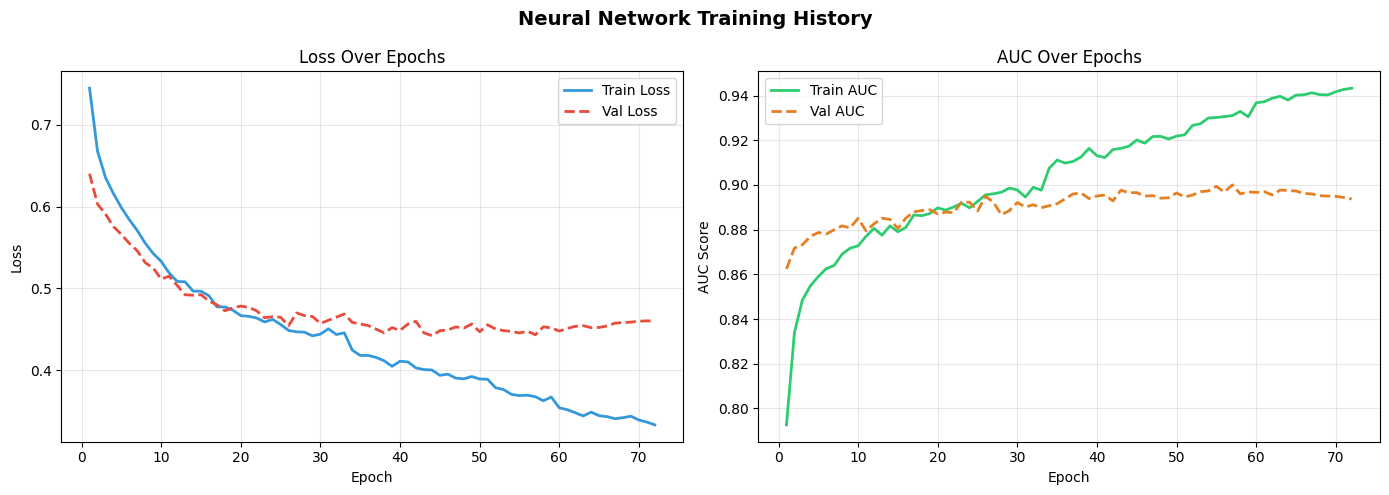


📊 HOW TO READ TRAINING CURVES:

✅ HEALTHY training:
   Train loss going DOWN + Val loss going DOWN together

⚠️  OVERFITTING:
   Train loss going DOWN but Val loss going UP
   Gap between train and val keeps growing

⚠️  UNDERFITTING:
   Both losses barely moving — model not learning
   Try more layers or more epochs



In [9]:
# ============================================
# TRAINING HISTORY VISUALIZATION
# Shows if model learned properly or overfit
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Training History', 
             fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['loss']) + 1)

# ── Plot 1: Loss ──────────────────────────────
axes[0].plot(epochs_range, history.history['loss'],
             label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val Loss',   color='#e74c3c', linewidth=2,
             linestyle='--')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Plot 2: AUC ───────────────────────────────
axes[1].plot(epochs_range, history.history['auc'],
             label='Train AUC', color='#2ecc71', linewidth=2)
axes[1].plot(epochs_range, history.history['val_auc'],
             label='Val AUC',   color='#e67e22', linewidth=2,
             linestyle='--')
axes[1].set_title('AUC Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/nn_training_history.png', dpi=150)
plt.show()

# ── What to look for ──────────────────────────
print("""
📊 HOW TO READ TRAINING CURVES:

✅ HEALTHY training:
   Train loss going DOWN + Val loss going DOWN together

⚠️  OVERFITTING:
   Train loss going DOWN but Val loss going UP
   Gap between train and val keeps growing

⚠️  UNDERFITTING:
   Both losses barely moving — model not learning
   Try more layers or more epochs
""")

In [14]:
# ============================================
# EVALUATE ON TEST SET
# ============================================
from sklearn.metrics          import (classification_report,
                                       confusion_matrix,
                                       roc_auc_score, roc_curve)
# Load best saved weights
model.load_weights('../models/best_nn_model.keras')

# Predict
y_pred_prob_nn = model.predict(X_test_sc, verbose=0).flatten()
y_pred_nn      = (y_pred_prob_nn >= 0.5).astype(int)

# Metrics
from sklearn.metrics import (accuracy_score, precision_score,
                               recall_score, f1_score)

accuracy  = accuracy_score(y_test, y_pred_nn)
precision = precision_score(y_test, y_pred_nn)
recall    = recall_score(y_test, y_pred_nn)
f1        = f1_score(y_test, y_pred_nn)
roc_auc   = roc_auc_score(y_test, y_pred_prob_nn)

print("=" * 55)
print("📊 NEURAL NETWORK — FINAL TEST RESULTS")
print("=" * 55)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred_nn, target_names=['No Churn','Churn'])}")

📊 NEURAL NETWORK — FINAL TEST RESULTS
  Accuracy  : 0.7417  (74.2%)
  Precision : 0.5109
  Recall    : 0.6257
  F1 Score  : 0.5625
  ROC-AUC   : 0.7915

              precision    recall  f1-score   support

    No Churn       0.85      0.78      0.82      1035
       Churn       0.51      0.63      0.56       374

    accuracy                           0.74      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.74      0.75      1409



In [ ]:
from pathlib import Path
import json

# Replace %run 03_MLModels.ipynb — load the notebook or .py without nbformat

py_path = Path('03_MLModels.py')
ipynb_path = Path('03_MLModels.ipynb')

if py_path.exists():
    import importlib.util
    spec = importlib.util.spec_from_file_location("mlmodels", str(py_path))
    ml = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(ml)
    globals().update({k: getattr(ml, k) for k in dir(ml) if not k.startswith("_")})
elif ipynb_path.exists():
    with ipynb_path.open('r', encoding='utf-8') as f:
        nb = json.load(f)
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            src = ''.join(cell.get('source', []))
            exec(src, globals())
else:
    raise FileNotFoundError("Neither 03_MLModels.py nor 03_MLModels.ipynb was found.")

ModuleNotFoundError: No module named 'nbformat'

In [ ]:
import pickle
from 03_MLModels import evaluate_model

# Load the saved model
with open('../models/lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)


lr_results = evaluate_model(
    'Logistic Regression',
    lr_model,
    X_train, y_train,
    X_test,  y_test
)
with open('../models/lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)


lr_results = evaluate_model(
    'Logistic Regression',
    lr_model,
    X_train, y_train,
    X_test,  y_test
)

with open('../models/lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)


lr_results = evaluate_model(
    'Logistic Regression',
    lr_model,
    X_train, y_train,
    X_test,  y_test
)

In [15]:
# ============================================
# FINAL COMPARISON — All 4 Models Together
# This is the money slide for interviews!
# ============================================

final_comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'ROC_AUC': lr_results['ROC_AUC'],
     'F1': lr_results['F1'], 'Recall': lr_results['Recall'],
     'Precision': lr_results['Precision']},
    {'Model': 'Random Forest',       'ROC_AUC': rf_results['ROC_AUC'],
     'F1': rf_results['F1'], 'Recall': rf_results['Recall'],
     'Precision': rf_results['Precision']},
    {'Model': 'XGBoost',             'ROC_AUC': xgb_results['ROC_AUC'],
     'F1': xgb_results['F1'], 'Recall': xgb_results['Recall'],
     'Precision': xgb_results['Precision']},
    {'Model': 'Neural Network',      'ROC_AUC': round(roc_auc, 4),
     'F1': round(f1, 4), 'Recall': round(recall, 4),
     'Precision': round(precision, 4)}
])

final_comparison = final_comparison.sort_values('ROC_AUC', ascending=False)

print("=" * 65)
print("🏆 FINAL MODEL COMPARISON — All Models")
print("=" * 65)
print(final_comparison.to_string(index=False))

best = final_comparison.iloc[0]['Model']
print(f"\n🥇 Overall Best Model: {best}")

NameError: name 'lr_results' is not defined

In [ ]:
# ── Final ROC Curve — All 4 Models ────────────
plt.figure(figsize=(10, 7))

model_data = [
    ('Logistic Regression', lr_results['y_pred_prob'],  '#3498db'),
    ('Random Forest',       rf_results['y_pred_prob'],  '#2ecc71'),
    ('XGBoost',             xgb_results['y_pred_prob'], '#e74c3c'),
    ('Neural Network',      y_pred_prob_nn,             '#9b59b6')
]

for name, probs, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score   = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr,
             label     = f"{name} (AUC={auc_score:.3f})",
             color     = color,
             linewidth = 2.5)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('Final ROC Curve — All Models Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/final_roc_comparison.png', dpi=150)
plt.show()

print("✅ Final comparison chart saved!")

In [ ]:
""""Input Layer     → 19 features enter here
                        ↓
Dense(128, relu)→ 128 neurons learn complex patterns
BatchNorm       → keeps values stable between layers
Dropout(0.3)    → randomly kills 30% neurons per batch
                        ↓
Dense(64, relu) → 64 neurons learn refined patterns
BatchNorm       → normalizes again
Dropout(0.3)    → prevents memorizing training data
                        ↓
Dense(32, relu) → 32 neurons — final pattern detection
BatchNorm       → normalizes
Dropout(0.2)    → lighter dropout near output
                        ↓
Dense(1,sigmoid)→ single probability between 0 and 1
                  > 0.5 = Churn prediction
                  < 0.5 = No Churn prediction """

In [ ]:
"""I added BatchNormalization after each Dense layer
 because it stabilizes the learning process and
 allows higher learning rates — this made training
 significantly faster.

 I used Dropout to prevent overfitting — the model
 was seeing the same 5600 training samples many
 times, so Dropout forced it to learn robust
 patterns rather than memorizing training data.

 Early Stopping with restore_best_weights meant
 I never had to manually tune epochs — the model
 automatically rolled back to its best state."""